### Configuration

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

#Base Path
BASE_DIR = Path.cwd() 
IO_DIR = BASE_DIR / "io"
IO_DIR.mkdir(parents=True, exist_ok=True)

PREPROCESS_DIR = IO_DIR / 'preprocessing'
PREPROCESS_DIR.mkdir(parents=True, exist_ok=True)

FEAT_ENGEERING_DIR = IO_DIR / 'feat_engineering'
FEAT_ENGEERING_DIR.mkdir(parents=True, exist_ok=True)

#Datasets
CASES_DATA = IO_DIR / 'ALLARMI.csv'
PASSENGERS_DATA = IO_DIR / 'TIPOLOGIA_VIAGGIATORE.csv'

#Output
CASES_CLEAN_OUT = PREPROCESS_DIR / 'cases_clean.csv'
PASSENGERS_CLEAN_OUT = PREPROCESS_DIR / 'passenger_clean.csv'
FEAT_ENGEERING_OUT = FEAT_ENGEERING_DIR / 'feat_engineered.csv'

#Translation of columns
COLUMN_MAPPING_PASSENGERS = {
    'AREOPORTO_ARRIVO': 'arrival_airport_code',
    'AREOPORTO_PARTENZA': 'departure_airport_code',
    'DATA_PARTENZA': 'departure_date',
    'DESCR_AEREOPORTO_ARR': 'arrival_airport_name',
    'DESCR_AEREOPORTO_PART': 'departure_airport_name',
    'CITTA_ARR': 'arrival_city',
    'CITTA_PARTENZA': 'departure_city',
    'CODICE_PAESE_ARR': 'arrival_country_code',
    'CODICE_PAESE_PART': 'departure_country_code',
    'PAESE_ARR': 'arrival_country',
    'PAESE_PART': 'departure_country',
    'ZONA': 'zone',
    'ENTRATI': 'passengers_entries_count',
    'INVESTIGATI': 'passengers_investigated_count',
    'ALLARMATI': 'passengers_flagged_count',
    'GENERE': 'gender',
    'FLAG_TRANSITO': 'transit_flag',
    'ESITO_CONTROLLO': 'control_result',
    'Tipo Documento': 'document_type',
    'FASCIA ETA': 'age_range',
    '3nazionalita': 'nationality',
    'compagnia%aerea': 'airline',
    'num volo': 'flight_number'
}

COLUMN_MAPPING_CASES = {
    'OCCORRENZE': 'event_type',
    'AREOPORTO_ARRIVO': 'arrival_airport_code',
    'AREOPORTO_PARTENZA': 'departure_airport_code',
    'DATA_PARTENZA': 'departure_date',
    'DESCR_AEREOPORTO_ARR': 'arrival_airport_name',
    'DESCR_AEREOPORTO_PART': 'departure_airport_name',
    'CITTA_ARR': 'arrival_city_name',
    'CITTA_PARTENZA': 'departure_city_name',
    'CODICE PAESE ARR': 'arrival_country_code',
    'CODICE_PAESE_PART': 'departure_country_code',
    'MOTIVO_ALLARME': 'alarm_reason',
    'paese%arr' : 'arrival_country_name',
    'Paese Partenza': 'departure_country_name',
    'tot voli': 'total_flights',
    '3zona': 'region_zone'
}

#Standardization of gender values
GENDER_MAPPING = {
    'F': 'F', 'f': 'F', 'Femmina': 'F', 'Female': 'F', 'FEMALE': 'F', '2': 'F',
    'M': 'M', 'm': 'M', 'Maschio': 'M', 'Male': 'M', 'MALE': 'M', '1': 'M',
    'X': 'Other/NB', 'N/B': 'Other/NB'
}

#3 Alpha Iso codes of countries for cases dataset.
COUNTRY_CODES = {
    'GB': 'GBR', 
    'EG': 'EGY', 
    'TR': 'TUR', 
    'AL': 'ALB', 
    'MA': 'MAR', 
    'AE': 'ARE'
}

#Feature Engineering Columns
ID_COLS = ["date", "route_city", "route_country", "route_airport"]
CALENDAR_COLS = ["year", "month", "day", "weekday", "is_weekend"]
BASE_COLS = ["entries", "investigated", "flagged","investigation_rate", "flag_rate", "flag_given_investigated"]

SEGMENT_COLS = ["nationality_count", "avg_nat_entries", "max_nat_entries", "avg_nat_flag_rate", "max_nat_flag_rate",
    "document_type_count", "avg_doc_entries", "max_doc_entries", "avg_doc_flag_rate", "max_doc_flag_rate",
    "airline_count", "avg_airline_entries", "max_airline_entries", "avg_airline_flag_rate", "max_airline_flag_rate",
    "control_result_count", "avg_control_entries", "max_control_entries", "avg_control_flag_rate", "max_control_flag_rate"]

CASE_COLS = [
    "has_case_match", "case_records", "total_flights",
    "unique_alarm_reasons", "unique_event_types","alarm_density_per_entry"]

CHANGE_COLS = ['entries_lag1','entries_diff1','entries_pct_change1',
    'investigated_lag1','investigated_diff1','investigated_pct_change1',
    'flagged_lag1','flagged_diff1','investigation_rate_lag1',
    'investigation_rate_diff1','investigation_rate_pct_change1','flag_rate_lag1','flag_rate_diff1']

VOLUME_FLAG_COLS = ["is_low_volume", "is_low_volume_50"]

ROLLING_COLS = ["entries_roll7", "entries_roll30", "entries_dev_ratio7", "flag_rate_roll7",
     "flag_rate_roll30", "flag_rate_dev_ratio7", "investigation_rate_roll7", "investigation_rate_roll30",
     "investigation_rate_dev_ratio7"]

SEASONAL_COLS = ["entries_trend", "entries_residual", "entries_residual_z"]

# Passengers Dataset 'TIPOLOGIA_VIAGGIATORE'

## 1) Importing data and skimming through

In [2]:
df_passengers = pd.read_csv(PASSENGERS_DATA)
df_passengers.head()

,NAZIONALITA,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,GIORNO_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,...,COMPAGNIA_AEREA,NUMERO_VOLO,ESITO_CONTROLLO,note_operatore,codice_rischio,Tipo Documento,FASCIA ETA,3nazionalita,compagnia%aerea,num volo
0,ALB,NAP,DUR,2024,02,13,2024-02-13 07:30:00,Napoli Capodichino,King Shaka International,Napoli,...,Fly Dubai,FZ1681,RESPINTO,NaN,NaN,Passaporto,N.D.,ALB,Fly Dubai,FZ1681
1,NaN,FCO,JFK,2024,01,22,2024-01-22 16:35:00,Fiumicino,John F Kennedy International,Roma,...,ITA Airways,AZ0609,NaN,NaN,NaN,Carta d'identità,18-30,ALB,ITA Airways,AZ0609
2,ALB,TSF,TIA,2024,02,4,2024-02-04 20:10:00,Treviso-Sant'Angelo,Rinas Mother Teresa,Treviso,...,Ryanair DAC,FR8400,SEGNALATO,NaN,NaN,N.D.,31-45,ALB,Ryanair DAC,FR8400
3,AFG,FCO,IST,2024,01,25,2024-01-25 13:05:00,Fiumicino,Havalimani,Roma,...,Turkish Airlines,TK1865,NaN,NaN,NaN,N.D.,61+,AFG,Turkish Airlines,TK1865
4,ALB,BGY,MLE,2024,02,13,FEB 13 2024,Orio al Serio,Male International,Bergamo,...,Fly Dubai,FZ1571,SEGNALATO,NaN,NaN,Permesso di soggiorno,46-60,ALB,Fly Dubai,FZ1571


In [3]:
display(df_passengers.columns, df_passengers.shape)
df_passengers.isnull().sum().sort_values(ascending=False)

Index(['NAZIONALITA', 'AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA',
       'ANNO_PARTENZA', 'MESE_PARTENZA', 'GIORNO_PARTENZA', 'DATA_PARTENZA',
       'DESCR_AEREOPORTO_ARR', 'DESCR_AEREOPORTO_PART', 'CITTA_ARR',
       'CITTA_PARTENZA', 'CODICE_PAESE_ARR', 'CODICE_PAESE_PART', 'PAESE_ARR',
       'PAESE_PART', 'ZONA', 'ENTRATI', 'INVESTIGATI', 'ALLARMATI',
       'TIPO_DOCUMENTO', 'GENERE', 'FASCIA_ETA', 'FLAG_TRANSITO',
       'COMPAGNIA_AEREA', 'NUMERO_VOLO', 'ESITO_CONTROLLO', 'note_operatore',
       'codice_rischio', 'Tipo Documento', 'FASCIA ETA', '3nazionalita',
       'compagnia%aerea', 'num volo'],
      dtype='object')

(5095, 33)

codice_rischio           5054
note_operatore           5034
ESITO_CONTROLLO          1289
NAZIONALITA               116
COMPAGNIA_AEREA            87
NUMERO_VOLO                70
TIPO_DOCUMENTO             62
GENERE                     45
INVESTIGATI                 0
compagnia%aerea             0
3nazionalita                0
FASCIA ETA                  0
Tipo Documento              0
FLAG_TRANSITO               0
FASCIA_ETA                  0
ALLARMATI                   0
ENTRATI                     0
AREOPORTO_ARRIVO            0
ZONA                        0
PAESE_PART                  0
PAESE_ARR                   0
CODICE_PAESE_PART           0
CODICE_PAESE_ARR            0
CITTA_PARTENZA              0
CITTA_ARR                   0
DESCR_AEREOPORTO_PART       0
DESCR_AEREOPORTO_ARR        0
DATA_PARTENZA               0
GIORNO_PARTENZA             0
MESE_PARTENZA               0
ANNO_PARTENZA               0
AREOPORTO_PARTENZA          0
num volo                    0
dtype: int

There are five duplicate columns that must be removed since they include inconsistent data. <br>
Placeholder values should be replaced (e.g., `N.D.`) with unknown. <br>
Logical constraints are enforced. There can't be more flagged passengers than entered passengers: 
- `ENTRATI ≥ INVESTIGATI ≥ ALLARMATI`



In [4]:
#Dropping very inconsistent columns
to_be_dropped = ['FASCIA_ETA', 'TIPO_DOCUMENTO', 'NAZIONALITA', 'NUMERO_VOLO', 'COMPAGNIA_AEREA', 'ANNO_PARTENZA', 'MESE_PARTENZA', 'GIORNO_PARTENZA', 'note_operatore', 'codice_rischio']
df_passengers.drop(columns=to_be_dropped, errors='ignore', inplace=True)

#Placceholder replacement for Gender Column
df_passengers['GENERE'] = df_passengers['GENERE'].map(GENDER_MAPPING).fillna('UNKNOWN')

#Cleaning and Standardization of rows related to passengers counts
df_passengers['ENTRATI'] = df_passengers['ENTRATI'].astype(str).str.replace('pax', '', case=False)
df_passengers['INVESTIGATI'] = df_passengers['INVESTIGATI'].astype(str).str.replace('pax', '', case=False)
df_passengers['ALLARMATI'] = df_passengers['ALLARMATI'].astype(str).str.replace('pax', '', case=False)

df_passengers['ENTRATI'] = df_passengers['ENTRATI'].str.replace('~', '').str.replace(',', '.')
df_passengers['INVESTIGATI'] = df_passengers['INVESTIGATI'].str.replace('~', '').str.replace(',', '.')
df_passengers['ALLARMATI'] = df_passengers['ALLARMATI'].str.replace('~', '').str.replace(',', '.')

df_passengers['ENTRATI'] = pd.to_numeric(df_passengers['ENTRATI'], errors='coerce').astype('Int64')
df_passengers['INVESTIGATI'] = pd.to_numeric(df_passengers['INVESTIGATI'], errors='coerce').astype('Int64')
df_passengers['ALLARMATI'] = pd.to_numeric(df_passengers['ALLARMATI'], errors='coerce').astype('Int64')

#Dropping rows where both core metrics are missing
df_passengers = df_passengers.dropna(subset=['ENTRATI', 'INVESTIGATI'], how='all').copy()

#Handling Negative Values in Passenger Counts
df_passengers.loc[df_passengers["INVESTIGATI"] < 0, "INVESTIGATI"] = 0
df_passengers.loc[df_passengers["ALLARMATI"] < 0, "ALLARMATI"] = 0
df_passengers.loc[df_passengers["ENTRATI"] < 0, "ENTRATI"] = 0

#Data Recovery Logic for Missing Values in Passenger Counts
#If Investigati is null, pull from Allarmati (because Allarmati <= Investigati) and If Entrati is null, pull from Investigati (because Investigati <= Entrati)
df_passengers['ALLARMATI'].fillna(0, inplace=True)
df_passengers['INVESTIGATI'] = df_passengers['INVESTIGATI'].fillna(df_passengers['ALLARMATI'])
df_passengers['ENTRATI'] = df_passengers['ENTRATI'].fillna(df_passengers['INVESTIGATI'])

#ENTRATI ≥ INVESTIGATI ≥ ALLARMATI Logic
valid_rows = ((df_passengers['ALLARMATI'] <= df_passengers['INVESTIGATI']) &
            (df_passengers['INVESTIGATI'] <= df_passengers['ENTRATI']) &
            (df_passengers['ENTRATI'] <= 853))
df_passengers = df_passengers[valid_rows].copy()


/var/folders/wn/mbbrj03n6c5bjyccn1th9tcm0000gn/T/ipykernel_4956/1588543199.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_passengers['ALLARMATI'].fillna(0, inplace=True)


Departure dates are not consistent, so they are all standardized

In [5]:
df_passengers['DATA_PARTENZA'] = df_passengers['DATA_PARTENZA'].str.upper().str.replace('GEN', 'JAN')
df_passengers['DATA_PARTENZA'] = pd.to_datetime(df_passengers['DATA_PARTENZA'], format='mixed', dayfirst=True)

In order to have a unifromity, country codes are held in 3 Alpha iso format. <br>
More standardization on several columns are applied. <br>
Columns are translated to English for a better readability 

In [6]:
#Placeholder replacement for strange values
placeholders = ['N.D.', 'n.d.', 'N/A', ' ', '?', '//']
df_passengers = df_passengers.replace(placeholders, 'UNKNOWN')
df_passengers['ESITO_CONTROLLO'] = df_passengers['ESITO_CONTROLLO'].fillna('UNKNOWN')
df_passengers = df_passengers.drop_duplicates()

#Iso code standardization for arrival country
df_passengers['CODICE_PAESE_ARR'] = df_passengers['CODICE_PAESE_ARR'].replace('IT', 'ITA')
df_passengers['CODICE_PAESE_PART'].replace(COUNTRY_CODES, inplace=True)

#Standardization of text columns to uppercase
df_passengers['AREOPORTO_ARRIVO'] = df_passengers['AREOPORTO_ARRIVO'].str.upper()
df_passengers['AREOPORTO_PARTENZA'] = df_passengers['AREOPORTO_PARTENZA'].str.upper()
df_passengers['CITTA_ARR'] = df_passengers['CITTA_ARR'].str.upper()
df_passengers['CITTA_PARTENZA']= df_passengers['CITTA_PARTENZA'].str.upper()
df_passengers['PAESE_ARR'] = df_passengers['PAESE_ARR'].str.upper()
df_passengers['PAESE_PART'] = df_passengers['PAESE_PART'].str.upper()
df_passengers['DESCR_AEREOPORTO_ARR'] = df_passengers['DESCR_AEREOPORTO_ARR'].str.upper()
df_passengers['DESCR_AEREOPORTO_PART'] = df_passengers['DESCR_AEREOPORTO_PART'].str.upper()

#Columns are translated to English
df_passengers.rename(columns=COLUMN_MAPPING_PASSENGERS, inplace=True)

/var/folders/wn/mbbrj03n6c5bjyccn1th9tcm0000gn/T/ipykernel_4956/2792531702.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_passengers['CODICE_PAESE_PART'].replace(COUNTRY_CODES, inplace=True)


Here how the dataset looks after preprocessing.

In [7]:
df_passengers.head()

,arrival_airport_code,departure_airport_code,departure_date,arrival_airport_name,departure_airport_name,arrival_city,departure_city,arrival_country_code,departure_country_code,arrival_country,...,passengers_investigated_count,passengers_flagged_count,gender,transit_flag,control_result,document_type,age_range,nationality,airline,flight_number
0,NAP,DUR,2024-02-13 07:30:00,NAPOLI CAPODICHINO,KING SHAKA INTERNATIONAL,NAPOLI,DURBAN,ITA,ZAF,ITALIA,...,1,0,F,Singola Tratta,RESPINTO,Passaporto,UNKNOWN,ALB,Fly Dubai,FZ1681
2,TSF,TIA,2024-02-04 20:10:00,TREVISO-SANT'ANGELO,RINAS MOTHER TERESA,TREVISO,TIRANA,ITA,ALB,ITALIA,...,58,13,F,Singola Tratta,SEGNALATO,UNKNOWN,31-45,ALB,Ryanair DAC,FR8400
3,FCO,IST,2024-01-25 13:05:00,FIUMICINO,HAVALIMANI,ROMA,ISTANBUL,ITA,TUR,ITALIA,...,1,0,M,Singola Tratta,UNKNOWN,UNKNOWN,61+,AFG,Turkish Airlines,TK1865
4,BGY,MLE,2024-02-13 00:00:00,ORIO AL SERIO,MALE INTERNATIONAL,BERGAMO,MALE,ITA,MDV,ITALIA,...,2,1,F,Singola Tratta,SEGNALATO,Permesso di soggiorno,46-60,ALB,Fly Dubai,FZ1571
5,TSF,LTN,2024-02-18 16:30:00,TREVISO-SANT'ANGELO,LONDON LUTON,TREVISO,LONDRA,ITA,GBR,ITALIA,...,3,0,F,Singola Tratta,RESPINTO,Carta d'identità,18-30,ALB,Ryanair DAC,FR1050


# Cases Dataset 'ALLARMI'

In [8]:
df_cases = pd.read_csv(CASES_DATA)
display(df_cases.head())
display(df_cases.columns)
df_cases.shape

,OCCORRENZE,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,CITTA_PARTENZA,...,ZONA,TOT,MOTIVO_ALLARME,note_operatore,flag_rischio,Paese Partenza,CODICE PAESE ARR,3zona,paese%arr,tot voli
0,Voli con Allarmi,FCO,IST,2024,01,2024-01-30 09:15:00,Fiumicino,Havalimani,Roma,Istanbul,...,5,1,Manuale,NaN,NaN,Turchia,ITA,5,Italia,1
1,Viaggiatori con Allarmi,CIA,STN,2024,02,2024-02-03 13:15:00,Ciampino,Stansted,Roma,Londra,...,5,5,Manuale,NaN,NaN,Regno Unito,ITA,5,Italia,5
2,Viaggiatori entrati nel Sistema,FCO,LHR,2024,01,2024-01-15 08:45:00,Fiumicino,London Heathrow,Roma,Londra,...,5,110,TSC,NaN,NaN,Regno Unito,ITA,5,Italia,110
3,Voli con Allarmi,MXP,LHR,2024,02,2024-02-02 08:40:00,Malpensa,London Heathrow,Milano,Londra,...,2,1,SDI,NaN,NaN,Regno Unito,ITA,2,Italia,1
4,Viaggiatori con Allarmi,PSA,BRS,2024,02,2024-02-16 12:50:00,Galileo Galilei,Bristol,Pisa,Bristol,...,8,2,INTERPOL,NaN,NaN,Regno Unito,ITA,8,Italia,2


Index(['OCCORRENZE', 'AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA', 'ANNO_PARTENZA',
       'MESE_PARTENZA', 'DATA_PARTENZA', 'DESCR_AEREOPORTO_ARR',
       'DESCR_AEREOPORTO_PART', 'CITTA_ARR', 'CITTA_PARTENZA',
       'CODICE_PAESE_ARR', 'CODICE_PAESE_PART', 'PAESE_ARR', 'PAESE_PART',
       'ZONA', 'TOT', 'MOTIVO_ALLARME', 'note_operatore', 'flag_rischio',
       'Paese Partenza', 'CODICE PAESE ARR', '3zona', 'paese%arr', 'tot voli'],
      dtype='object')

(5080, 24)

The columns that are so inconsistent or redundant are dropped.

In [9]:
columns_to_be_dropped = ['PAESE_ARR', 'PAESE_PART', 'ZONA',
                         'note_operatore', 'flag_rischio','ANNO_PARTENZA', 
                         'MESE_PARTENZA', 'TOT', 'CODICE_PAESE_ARR']

df_cases.drop(columns=columns_to_be_dropped, errors='ignore', inplace=True)

As we observed in the previous dataset, here the column are filled with placeholders and require standardization.

In [10]:
df_cases = df_cases.drop_duplicates()

#Anything else than digits are removed
df_cases['tot voli'] = df_cases['tot voli'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0).astype(int)

#Standardization of months
df_cases['DATA_PARTENZA'] = df_cases['DATA_PARTENZA'].astype(str).str.upper().str.replace('GEN', 'JAN')
df_cases['DATA_PARTENZA'] = pd.to_datetime(df_cases['DATA_PARTENZA'], format='mixed', dayfirst=True, errors='coerce')

#Standardization of text columns to uppercase
df_cases['AREOPORTO_ARRIVO'] = df_cases['AREOPORTO_ARRIVO'].str.upper()
df_cases['AREOPORTO_PARTENZA'] = df_cases['AREOPORTO_PARTENZA'].str.upper()
df_cases['DESCR_AEREOPORTO_ARR'] = df_cases['DESCR_AEREOPORTO_ARR'].str.upper()
df_cases['DESCR_AEREOPORTO_PART'] = df_cases['DESCR_AEREOPORTO_PART'].str.upper()

#Placeholder replacement for occorrenze column
placeholders = ['???', 'N/C', 'Altro']
df_cases['OCCORRENZE'] = df_cases['OCCORRENZE'].replace(placeholders, 'UNKNOWN')

#Placeholder replacement for departure airport name, if not available, pull from departure airport code
placeholders = [' ', '?', 'N.D.', 'ND', '-', '//', 'N/A ', '  ', '- ', 'N/A', '','NULL']
df_cases['DESCR_AEREOPORTO_PART'] = df_cases['DESCR_AEREOPORTO_PART'].str.upper().str.strip()
df_cases['DESCR_AEREOPORTO_PART'] = df_cases['DESCR_AEREOPORTO_PART'].replace(placeholders, np.nan)
df_cases['DESCR_AEREOPORTO_PART'] = df_cases['DESCR_AEREOPORTO_PART'].fillna(df_cases['AREOPORTO_PARTENZA'])

#Placeholder replacement for departure country code, if not available, pull from departure country name, otherwise set to UNKNOWN with reference to departure country name
placeholders = ['n.d.', 'ND', '?', 'unknown', 'EU', 'XX', '00', '//', '-', 'ZZ', ' ']
df_cases['CODICE_PAESE_PART'] = df_cases['CODICE_PAESE_PART'].replace(COUNTRY_CODES)
df_cases['CODICE_PAESE_PART'] = df_cases['CODICE_PAESE_PART'].replace(placeholders, 'UNKNOWN')
df_cases['CODICE_PAESE_PART'].fillna('UNKNOWN', inplace=True)
df_cases['CODICE_PAESE_PART'] = df_cases['CODICE_PAESE_PART'].str.upper()

reference_map = df_cases[df_cases['CODICE_PAESE_PART'] != 'UNKNOWN'].set_index('Paese Partenza')['CODICE_PAESE_PART'].to_dict()
df_cases.loc[df_cases['CODICE_PAESE_PART'] == 'UNKNOWN', 'CODICE_PAESE_PART'] = df_cases['Paese Partenza'].map(reference_map)

#Placeholder replacement for departure city, if not available, set to UNKNOWN with reference to departure country name
df_cases['CITTA_PARTENZA'].fillna('unknown', inplace=True)
df_cases['CITTA_PARTENZA'] = df_cases.apply(lambda row: f"UNKNOWN ({row['Paese Partenza']})" if row['CITTA_PARTENZA'] in placeholders else row['CITTA_PARTENZA'],axis=1)

#More columns to be standardized as uppercase
df_cases['Paese Partenza'] = df_cases['Paese Partenza'].str.upper()
df_cases['CITTA_ARR'] = df_cases['CITTA_ARR'].str.upper()
df_cases['CITTA_PARTENZA'] = df_cases['CITTA_PARTENZA'].str.upper()
df_cases['paese%arr'] = df_cases['paese%arr'].str.upper()
df_cases['MOTIVO_ALLARME'] = df_cases['MOTIVO_ALLARME'].str.upper()

df_cases['MOTIVO_ALLARME'].fillna('UNKNOWN', inplace=True)

/var/folders/wn/mbbrj03n6c5bjyccn1th9tcm0000gn/T/ipykernel_4956/1511321091.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cases['CODICE_PAESE_PART'].fillna('UNKNOWN', inplace=True)
/var/folders/wn/mbbrj03n6c5bjyccn1th9tcm0000gn/T/ipykernel_4956/1511321091.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are settin

A country can't be in multiple regions.

In [11]:
country_zone_map = df_cases.groupby('CODICE_PAESE_PART')['3zona'].agg(lambda x: x.mode().iloc[0]).to_dict()
df_cases['3zona'] = df_cases['CODICE_PAESE_PART'].map(country_zone_map)

Lastly, the columns are translated to English

In [12]:
df_cases.rename(columns=COLUMN_MAPPING_CASES, inplace=True)

Here how 'ALLARMI' looks after preprocessing

In [13]:
df_cases.head()

,event_type,arrival_airport_code,departure_airport_code,departure_date,arrival_airport_name,departure_airport_name,arrival_city_name,departure_city_name,departure_country_code,alarm_reason,departure_country_name,arrival_country_code,region_zone,arrival_country_name,total_flights
0,Voli con Allarmi,FCO,IST,2024-01-30 09:15:00,FIUMICINO,HAVALIMANI,ROMA,ISTANBUL,TUR,MANUALE,TURCHIA,ITA,5,ITALIA,1
1,Viaggiatori con Allarmi,CIA,STN,2024-02-03 13:15:00,CIAMPINO,STANSTED,ROMA,LONDRA,GBR,MANUALE,REGNO UNITO,ITA,2,ITALIA,5
2,Viaggiatori entrati nel Sistema,FCO,LHR,2024-01-15 08:45:00,FIUMICINO,LONDON HEATHROW,ROMA,LONDRA,GBR,TSC,REGNO UNITO,ITA,2,ITALIA,110
3,Voli con Allarmi,MXP,LHR,2024-02-02 08:40:00,MALPENSA,LONDON HEATHROW,MILANO,LONDRA,GBR,SDI,REGNO UNITO,ITA,2,ITALIA,1
4,Viaggiatori con Allarmi,PSA,BRS,2024-02-16 12:50:00,GALILEO GALILEI,BRISTOL,PISA,BRISTOL,GBR,INTERPOL,REGNO UNITO,ITA,2,ITALIA,2


### Output are saved

In [14]:
df_cases.to_csv(CASES_CLEAN_OUT,index=False)
df_passengers.to_csv(PASSENGERS_CLEAN_OUT,index=False)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
passenger = pd.read_csv(PASSENGERS_CLEAN_OUT)
cases = pd.read_csv(CASES_CLEAN_OUT)

In [17]:
cases.columns

Index(['event_type', 'arrival_airport_code', 'departure_airport_code',
       'departure_date', 'arrival_airport_name', 'departure_airport_name',
       'arrival_city_name', 'departure_city_name', 'departure_country_code',
       'alarm_reason', 'departure_country_name', 'arrival_country_code',
       'region_zone', 'arrival_country_name', 'total_flights'],
      dtype='object')

In [18]:
passenger.columns

Index(['arrival_airport_code', 'departure_airport_code', 'departure_date',
       'arrival_airport_name', 'departure_airport_name', 'arrival_city',
       'departure_city', 'arrival_country_code', 'departure_country_code',
       'arrival_country', 'departure_country', 'zone',
       'passengers_entries_count', 'passengers_investigated_count',
       'passengers_flagged_count', 'gender', 'transit_flag', 'control_result',
       'document_type', 'age_range', 'nationality', 'airline',
       'flight_number'],
      dtype='object')

### Analytical Grain

The dataset is aggregated at:

**`date × route_airport`**

This grain was selected because:
- it guarantees uniqueness
- it aligns best with operational behavior
- it provides the most precise level for anomaly detection

`route_city` and `route_country` are retained for interpretability.

Time based features: year, month, day, hour, weekday and is_weekend

In [19]:
passenger["departure_date"] = pd.to_datetime(passenger["departure_date"], errors="coerce")
cases["departure_date"] = pd.to_datetime(cases["departure_date"], errors="coerce")

passenger["year"] = passenger["departure_date"].dt.year
passenger["month"] = passenger["departure_date"].dt.month
passenger["day"] = passenger["departure_date"].dt.day
passenger["hour"] = passenger["departure_date"].dt.hour
passenger["weekday"] = passenger["departure_date"].dt.dayofweek   #Monday is 0
passenger["is_weekend"] = passenger["weekday"].isin([5, 6]).astype(int)

cases["year"] = cases["departure_date"].dt.year
cases["month"] = cases["departure_date"].dt.month
cases["day"] = cases["departure_date"].dt.day
cases["hour"] = cases["departure_date"].dt.hour
cases["weekday"] = cases["departure_date"].dt.dayofweek
cases["is_weekend"] = cases["weekday"].isin([5, 6]).astype(int)

passenger["date"] = passenger["departure_date"].dt.floor("D")
cases["date"] = cases["departure_date"].dt.floor("D")

passenger["document_type"] = passenger["document_type"].fillna("UNKNOWN")
cases["alarm_reason"] = cases["alarm_reason"].fillna("UNKNOWN")

Route based features: route_country, route_city and route_airport

In [20]:
passenger["route_country"] = passenger["departure_country_code"].astype(str) + "_" + passenger["arrival_country_code"].astype(str)
passenger["route_city"] = passenger["departure_city"].astype(str) + "_" + passenger["arrival_city"].astype(str)
passenger["route_airport"] = passenger["departure_airport_code"].astype(str) + "_" + passenger["arrival_airport_code"].astype(str)

cases["route_country"] = cases["departure_country_code"].astype(str) + "_" + cases["arrival_country_code"].astype(str)
cases["route_city"] = cases["departure_city_name"].astype(str) + "_" + cases["arrival_city_name"].astype(str)
cases["route_airport"] = cases["departure_airport_code"].astype(str) + "_" + cases["arrival_airport_code"].astype(str)

Ratio based features: investigation_rate, flag_rate and flag_given_investigated
Since there are suspicous rows which are having a very low amount of entries, it's <br>
better to not rely on them directly. A new feature is added in order to be able to filter it later on.

In [21]:
passenger["is_low_volume"] = (passenger["passengers_entries_count"] < 10).astype(int)

passenger["investigation_rate"] = np.where(passenger["passengers_entries_count"] > 0, passenger["passengers_investigated_count"] / passenger["passengers_entries_count"], np.nan)
passenger["flag_rate"] = np.where(passenger["passengers_entries_count"] > 0, passenger["passengers_flagged_count"] / passenger["passengers_entries_count"], np.nan)
passenger["flag_given_investigated"] = np.where(passenger["passengers_investigated_count"] > 0, passenger["passengers_flagged_count"] / passenger["passengers_investigated_count"], np.nan)

### Base Table
Building a core daily route table using base features like routes, passenger counts and dates.
It captures:
- passenger volume
- control intensity
- flagged outcomes

In [22]:
route_daily = (passenger.groupby(["date", "route_airport"], as_index=False)
    .agg(route_city=("route_city", "first"),
        route_country=("route_country", "first"),
        entries=("passengers_entries_count", "sum"),
        investigated=("passengers_investigated_count", "sum"),
        flagged=("passengers_flagged_count", "sum")
    ))

route_daily["investigation_rate"] = np.where(route_daily["entries"] > 0, route_daily["investigated"] / route_daily["entries"], np.nan)
route_daily["flag_rate"] = np.where(route_daily["entries"] > 0, route_daily["flagged"] / route_daily["entries"], np.nan)
route_daily["flag_given_investigated"] = np.where(route_daily["investigated"] > 0, route_daily["flagged"] / route_daily["investigated"], np.nan)

route_daily["year"] = route_daily["date"].dt.year
route_daily["month"] = route_daily["date"].dt.month
route_daily["day"] = route_daily["date"].dt.day
route_daily["weekday"] = route_daily["date"].dt.dayofweek
route_daily["is_weekend"] = route_daily["weekday"].isin([5, 6]).astype(int)

route_daily.head()

,date,route_airport,route_city,route_country,entries,investigated,flagged,investigation_rate,flag_rate,flag_given_investigated,year,month,day,weekday,is_weekend
0,2023-12-31,JFK_FCO,NEW YORK_ROMA,USA_ITA,3,3,0,1.0,0.0,0.0,2023,12,31,6,1
1,2024-01-01,ADB_MXP,SMIRNE_MILANO,TUR_ITA,1,1,0,1.0,0.0,0.0,2024,1,1,0,0
2,2024-01-01,AMM_FCO,AMMAN_ROMA,JOR_ITA,2,0,0,0.0,0.0,NaN,2024,1,1,0,0
3,2024-01-01,BEG_BGY,BELGRADO_BERGAMO,SRB_ITA,1,1,0,1.0,0.0,0.0,2024,1,1,0,0
4,2024-01-01,BFS_BGY,BELFAST_BERGAMO,GBR_ITA,1,1,0,1.0,0.0,0.0,2024,1,1,0,0


### Daily Route + Nationality Features
First a table based on route_city + nationality is created and then will be merged with the base table.

In [23]:
route_nat_daily = (passenger.groupby(["date", "route_airport", "nationality"], as_index=False)
                .agg(nat_entries=("passengers_entries_count", "sum"),
                    nat_investigated=("passengers_investigated_count", "sum"),
                    nat_flagged=("passengers_flagged_count", "sum")))

route_nat_daily["nat_investigation_rate"] = np.where(route_nat_daily["nat_entries"] > 0, route_nat_daily["nat_investigated"] / route_nat_daily["nat_entries"],np.nan)
route_nat_daily["nat_flag_rate"] = np.where(route_nat_daily["nat_entries"] > 0, route_nat_daily["nat_flagged"] / route_nat_daily["nat_entries"],np.nan)

In [24]:
nat_features = (route_nat_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(nationality_count=("nationality", "nunique"),
        avg_nat_entries=("nat_entries", "mean"),
        max_nat_entries=("nat_entries", "max"),
        avg_nat_flag_rate=("nat_flag_rate", "mean"),
        max_nat_flag_rate=("nat_flag_rate", "max")))

route_daily = route_daily.merge(nat_features,on=["date", "route_airport"],how="left")

Document Type Features

In [25]:
route_doc_daily = (passenger.groupby(["date", "route_airport", "document_type"], as_index=False)
    .agg(doc_entries=("passengers_entries_count", "sum"),
        doc_investigated=("passengers_investigated_count", "sum"),
        doc_flagged=("passengers_flagged_count", "sum")))

route_doc_daily["doc_investigation_rate"] = np.where(route_doc_daily["doc_entries"] > 0, route_doc_daily["doc_investigated"] / route_doc_daily["doc_entries"],np.nan)
route_doc_daily["doc_flag_rate"] = np.where(route_doc_daily["doc_entries"] > 0, route_doc_daily["doc_flagged"] / route_doc_daily["doc_entries"],np.nan)

doc_features = (route_doc_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(document_type_count=("document_type", "nunique"),
        avg_doc_entries=("doc_entries", "mean"),
        max_doc_entries=("doc_entries", "max"),
        avg_doc_flag_rate=("doc_flag_rate", "mean"),
        max_doc_flag_rate=("doc_flag_rate", "max")))

route_daily = route_daily.merge(doc_features,on=["date", "route_airport"],how="left")

Airline Features

In [26]:
route_airline_daily = (passenger.groupby(["date", "route_airport", "airline"], as_index=False)
        .agg(airline_entries=("passengers_entries_count", "sum"),
        airline_investigated=("passengers_investigated_count", "sum"),
        airline_flagged=("passengers_flagged_count", "sum")))

route_airline_daily["airline_flag_rate"] = np.where(route_airline_daily["airline_entries"] > 0, route_airline_daily["airline_flagged"] / route_airline_daily["airline_entries"],np.nan)

airline_features = (route_airline_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(airline_count=("airline", "nunique"),
        avg_airline_entries=("airline_entries", "mean"),
        max_airline_entries=("airline_entries", "max"),
        avg_airline_flag_rate=("airline_flag_rate", "mean"),
        max_airline_flag_rate=("airline_flag_rate", "max")))

route_daily = route_daily.merge(airline_features,on=["date", "route_airport"],how="left")

Control Results Features

In [27]:
route_control_daily = (passenger.groupby(["date", "route_airport", "control_result"], dropna=False, as_index=False)
    .agg(control_entries=("passengers_entries_count", "sum"),
        control_investigated=("passengers_investigated_count", "sum"),
        control_flagged=("passengers_flagged_count", "sum")))

route_control_daily["control_flag_rate"] = np.where(route_control_daily["control_entries"] > 0,route_control_daily["control_flagged"] / route_control_daily["control_entries"],np.nan)

control_features = (route_control_daily.groupby(["date", "route_airport"], as_index=False)
    .agg(control_result_count=("control_result", "nunique"),
        avg_control_entries=("control_entries", "mean"),
        max_control_entries=("control_entries", "max"),
        avg_control_flag_rate=("control_flag_rate", "mean"),
        max_control_flag_rate=("control_flag_rate", "max")))

route_daily = route_daily.merge(control_features,on=["date", "route_airport"],how="left")

Cases Dataset Features + Merge on the main table

In [28]:
cases_route_daily = (cases.groupby(["date", "route_airport"], as_index=False)
    .agg(case_records=("event_type", "size"),
        total_flights=("total_flights", "sum"),
        unique_alarm_reasons=("alarm_reason", "nunique"),
        unique_event_types=("event_type", "nunique")))

route_daily = route_daily.merge(cases_route_daily,on=["date", "route_airport"],how="left")

route_daily["has_case_match"] = route_daily["case_records"].notna().astype(int)
route_daily["alarm_density_per_entry"] = np.where(route_daily["entries"] > 0,route_daily["case_records"] / route_daily["entries"],np.nan)

route_daily = route_daily.sort_values(["route_airport", "date"]).reset_index(drop=True)

Changes in Features
In order to observe trends in the change of entries and change of flag rate over time, the top 3 routes are visualized below.


In [29]:
change_cols = ["entries", "investigated", "flagged", "investigation_rate", "flag_rate"]

for col in change_cols:
    route_daily[f"{col}_lag1"] = route_daily.groupby("route_airport")[col].shift(1)
    route_daily[f"{col}_diff1"] = route_daily[col] - route_daily[f"{col}_lag1"]
    route_daily[f"{col}_pct_change1"] = np.where(route_daily[f"{col}_lag1"].notna() & (route_daily[f"{col}_lag1"] != 0),
        (route_daily[col] - route_daily[f"{col}_lag1"]) / route_daily[f"{col}_lag1"],np.nan)

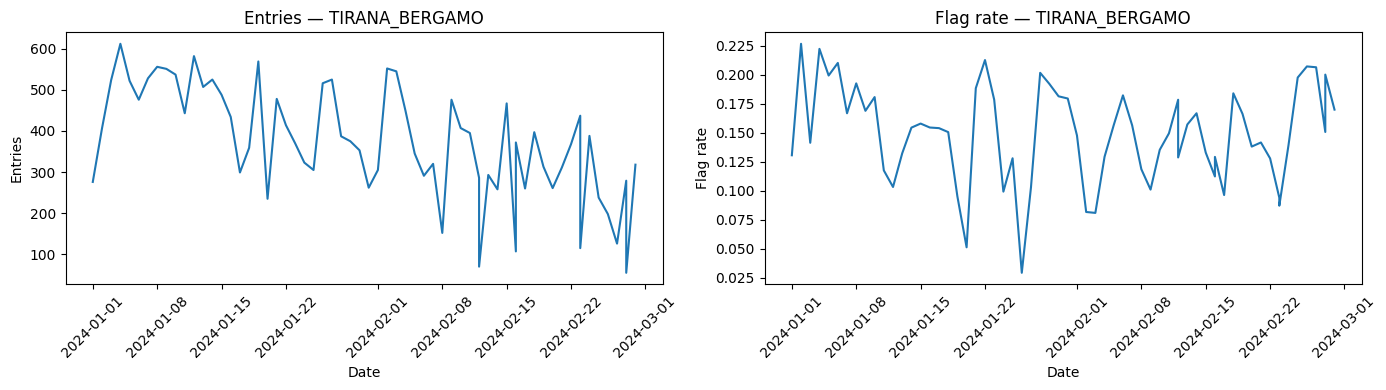

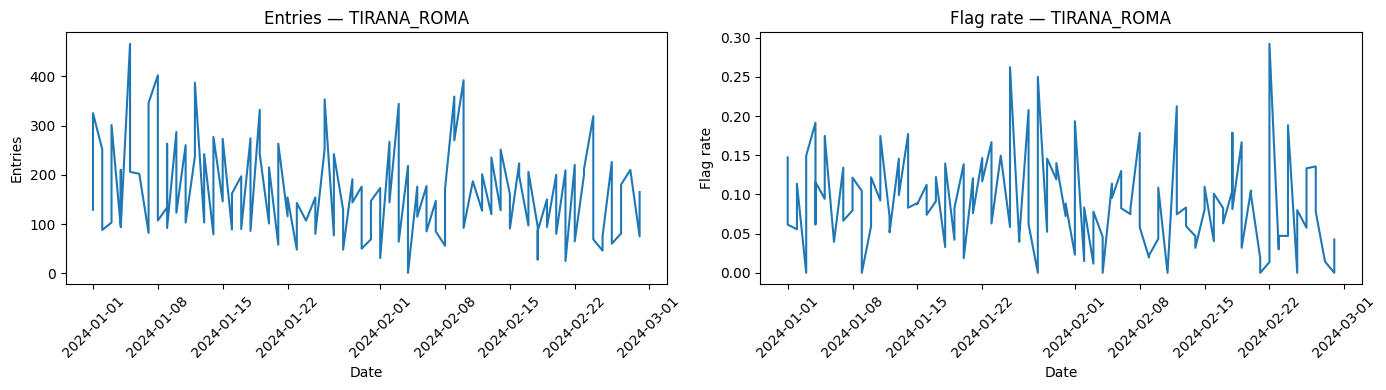

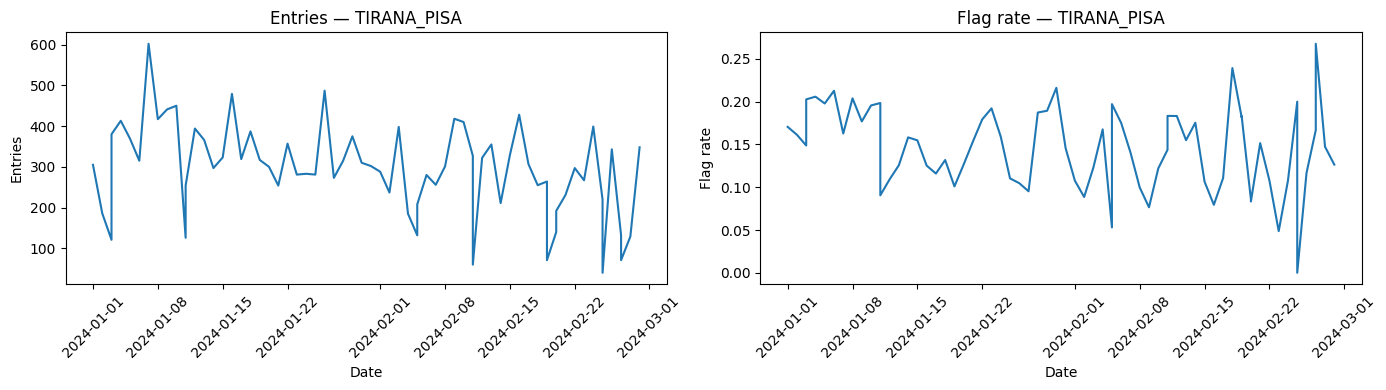

In [30]:
top_routes = route_daily.groupby("route_city")["entries"].sum().sort_values(ascending=False).head(3).index.tolist()

for route in top_routes:
    tmp = route_daily[route_daily["route_city"] == route].sort_values("date")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
    axes[0].plot(tmp["date"], tmp["entries"])
    axes[0].set_title(f"Entries — {route}")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Entries")

    axes[1].plot(tmp["date"], tmp["flag_rate"])
    axes[1].set_title(f"Flag rate — {route}")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Flag rate")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

From this plot below we can see that most of our entries in the dataset are few amount of entries. So we can't just drop those entries that have low_volume flag

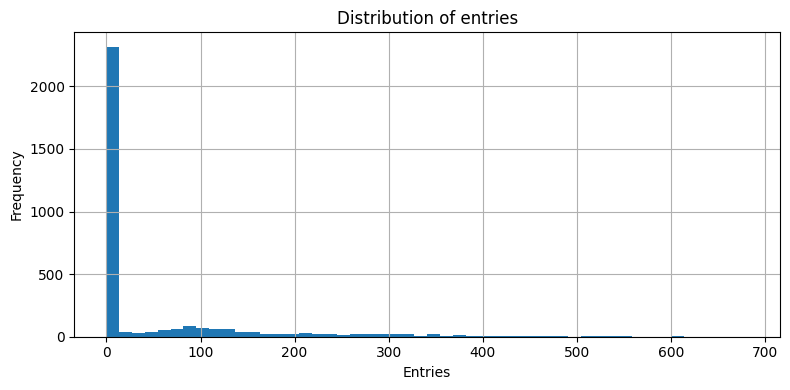

In [31]:
low_volume_rows = route_daily[route_daily["entries"] < 10].copy()
low_volume_rows[["date", "route_city", "entries", "investigated", "flagged", "flag_rate"]].head(20)

route_daily["entries"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
plt.figure(figsize=(8, 4))
route_daily["entries"].dropna().hist(bins=50)
plt.title("Distribution of entries")
plt.xlabel("Entries")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [32]:
fill_zero_cols = ["case_records","total_flights","unique_alarm_reasons","unique_event_types"]

for col in fill_zero_cols:
    if col in route_daily.columns:
        route_daily[col] = route_daily[col].fillna(0)

In [33]:
route_daily["alarm_density_per_entry"] = np.where(route_daily["entries"] > 0, route_daily["case_records"] / route_daily["entries"], np.nan)

Since 'flagged_pct_change1' and 'flag_rate_pct_change1' contains so many missing values (more than 50% they must be dropped).

In [34]:
route_daily.drop(columns=['flagged_pct_change1', 'flag_rate_pct_change1'], inplace=True, errors='ignore')

In [35]:
missing_report = (
    route_daily.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "column"})
)

missing_report.head(30)

,column,missing_pct
0,investigation_rate_pct_change1,0.199324
1,investigated_pct_change1,0.199017
2,flag_rate_diff1,0.159091
3,investigation_rate_diff1,0.159091
4,flag_rate_lag1,0.158784
5,investigation_rate_lag1,0.158784
6,entries_pct_change1,0.158784
7,entries_lag1,0.158170
8,investigated_lag1,0.158170
9,investigated_diff1,0.158170


In [36]:
route_daily["is_low_volume"] = (route_daily["entries"] < 10).astype(int)
route_daily["is_low_volume_50"] = (route_daily["entries"] < 50).astype(int)
print("Rows with entries < 10:", route_daily["is_low_volume"].sum())
print("Rows with entries < 50:", route_daily["is_low_volume_50"].sum())

Rows with entries < 10: 2297
Rows with entries < 50: 2407


In [37]:
full_feature_cols = (ID_COLS + CALENDAR_COLS + BASE_COLS + SEGMENT_COLS + CASE_COLS + CHANGE_COLS + VOLUME_FLAG_COLS)
full_feature_cols = [column for column in full_feature_cols if column in route_daily.columns]

feature_engineered_full = route_daily[full_feature_cols].copy()

print(feature_engineered_full.shape)
feature_engineered_full.head()

(3256, 56)


,date,route_city,route_country,route_airport,year,month,day,weekday,is_weekend,entries,...,investigated_pct_change1,flagged_lag1,flagged_diff1,investigation_rate_lag1,investigation_rate_diff1,investigation_rate_pct_change1,flag_rate_lag1,flag_rate_diff1,is_low_volume,is_low_volume_50
0,2024-02-03,ABIDJAN_CAGLIARI,CIV_ITA,ABJ_CAG,2024,2,3,5,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1,2024-01-08,SMIRNE_BERGAMO,TUR_ITA,ADB_BGY,2024,1,8,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
2,2024-02-01,SMIRNE_ROMA,TUR_ITA,ADB_FCO,2024,2,1,3,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
3,2024-01-01,SMIRNE_MILANO,TUR_ITA,ADB_MXP,2024,1,1,0,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
4,2024-01-15,SMIRNE_MILANO,TUR_ITA,ADB_MXP,2024,1,15,0,0,2,...,1.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,1,1


In [38]:
feature_engineered_full.to_csv(FEAT_ENGEERING_OUT, index=False)

# Anomaly Detection Classical Pipeline

Input: feat_engineered.csv  
Output: anomaly_scores.csv 

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings("ignore")

## 1. Load Feature-Engineered Dataset

In [40]:
df = pd.read_csv(FEAT_ENGEERING_OUT)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["route_airport", "date"]).reset_index(drop=True)

We want to try and measure the execution time of the classical, and then we'll do the same for the agentic pipeline

In [41]:
import time
pipeline_start = time.time()

## 2. Historical Baselines

Here we want to establish what "normal" looks like for each route, so that the anomaly detection models can identify meaningful deviations rather than reacting to raw values alone.
We build two types of baselines:

1. Rolling averages (7-obs and 30-obs windows): capture recent trends per route
2. Monthly seasonal baselines: capture recurring monthly patterns per route

### Rolling Averages

For each route, we compute rolling means over the last 7 and 30 observations on three key metrics: entries, flag_rate, and investigation_rate.
Why observation-based windows rather than calendar-based? Because our data is irregular the median gap between consecutive observations on the same route is 3 days, and some routes have gaps of weeks or months. A calendar-based "7-day window" would often contain just 1–2 data points, making the average unreliable. Using observation-based windows ensures each rolling mean is built on a sufficient number of actual data points.
We also compute a deviation ratio, which is the current value divided by the 7-observation rolling mean. A deviation ratio of 3.0 means "this observation is 3× the recent average"
The rolling 7-obs average covers 75% of the dataset. The remaining 25% consists of routes with fewer than 3 observations, for which the rolling mean cannot be computed. These are handled in the missing value imputation step.

In [42]:
rolling_targets = ["entries"]

for col in rolling_targets:
    # 7-observation rolling mean (min 3 observations required)
    df[f"{col}_roll7"] = (
    df.groupby("route_airport")[col]
    .transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
    )

    df[f"{col}_roll30"] = (
    df.groupby("route_airport")[col]
    .transform(lambda s: s.shift(1).rolling(30, min_periods=7).mean())
    )
    # Deviation ratio: current value / 7-obs rolling mean
    df[f"{col}_dev_ratio7"] = np.where(
        df[f"{col}_roll7"].notna() & (df[f"{col}_roll7"] > 0),
        df[col] / df[f"{col}_roll7"],
        np.nan
    )

### Monthly Seasonal Baselines

Standard seasonal decomposition requires regularly-spaced daily data. Our dataset is too irregular for this, routes have a median of just 2 observations, spread over several months with large gaps.
Instead, we compute a monthly seasonal baseline, for each route_airport × month, we calculate the average entries. The residual is the difference between the actual entries and this monthly baseline. Routes that consistently have high traffic in summer and low in winter will have small residuals during those months, but if a winter day suddenly shows summer-level traffic, the residual will be large.
We normalize the residual into a z-score per route, so that a value of ±2 means "this observation is 2 standard deviations away from the monthly norm for this route".
Additionally, we compute a route-level mean as a static reference: the overall average entries for each route, and how far each observation deviates from it.

In [43]:
# Monthly baseline: average entries per route × month
df["entries_monthly_baseline"] = (
    df.groupby(["route_airport", "month"])["entries"]
    .transform(lambda s: s.shift(1).expanding(min_periods=3).mean())
)
df["entries_residual"] = df["entries"] - df["entries_monthly_baseline"]

# Normalize residual to z-score per route
df["entries_residual_std"] = (
    df.groupby("route_airport")["entries_residual"]
    .transform(lambda s: s.shift(1).expanding(min_periods=7).std())
)

df["entries_residual_z"] = np.where(
    df["entries_residual_std"].notna() & (df["entries_residual_std"] > 0),
    df["entries_residual"] / df["entries_residual_std"],
    np.nan
)

# Route-level static baseline
df = df.sort_values(["route_airport", "date"])

df["entries_route_mean"] = (
    df.groupby("route_airport")["entries"]
    .transform(lambda s: s.shift(1).expanding(min_periods=7).mean())
)
df["entries_vs_route_mean"] = np.where(
    df["entries_route_mean"] > 0,
    df["entries"] / df["entries_route_mean"],
    np.nan
)

### Baselines vs Actuals

To verify that the rolling averages are capturing meaningful patterns, we plot `entries` and `flag_rate` alongside their 7-observation rolling means for the top 3 routes by total traffic. We also show the monthly seasonal residuals.

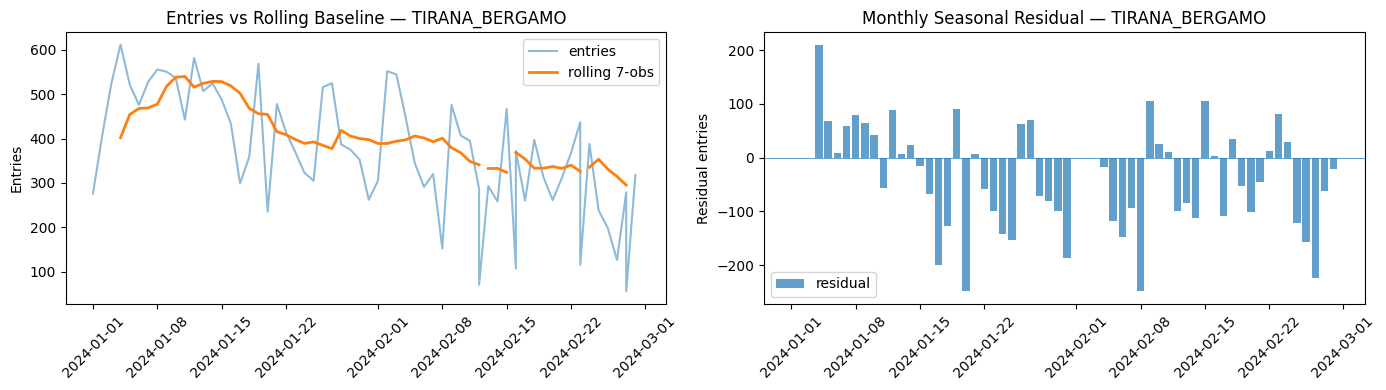

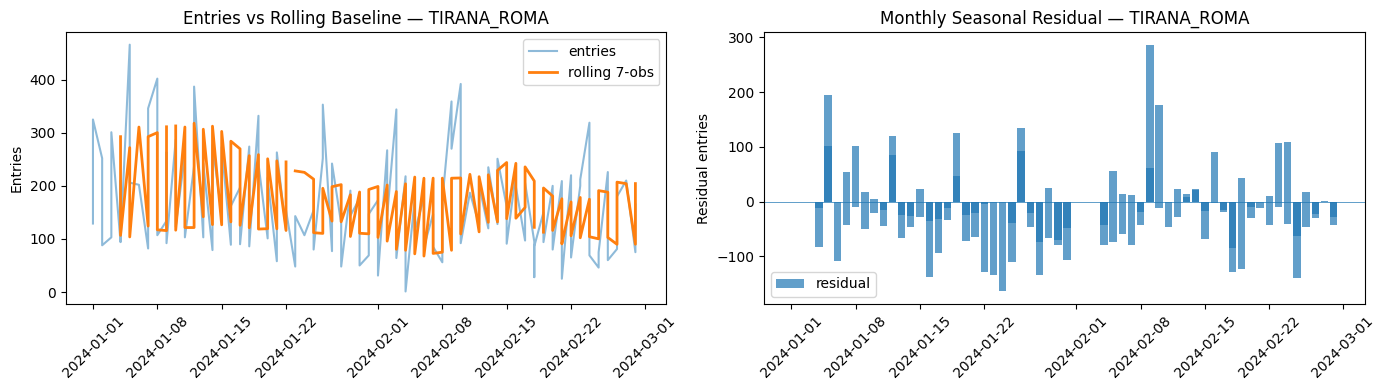

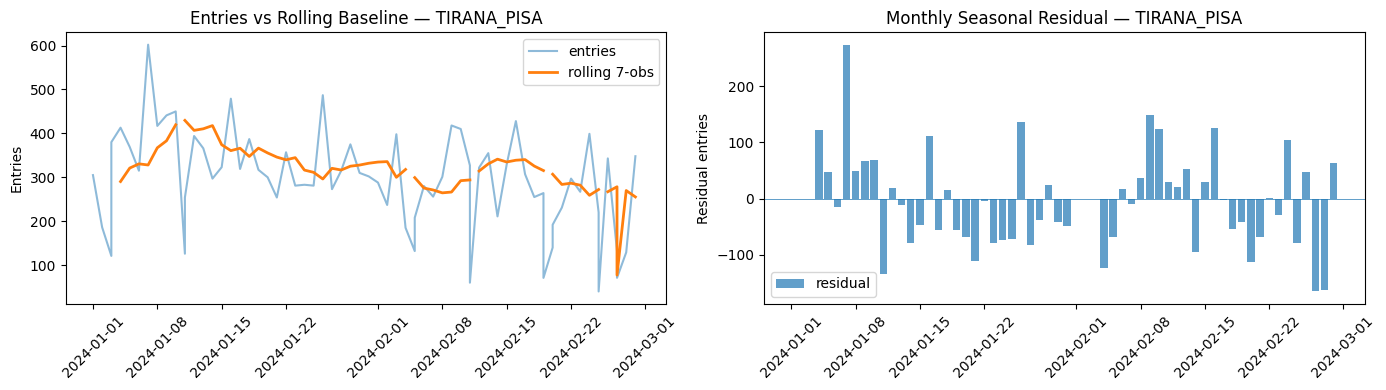

In [44]:
top_routes = (df.groupby("route_city")["entries"]
              .sum().sort_values(ascending=False).head(3).index.tolist())

for route in top_routes:
    tmp = df[df["route_city"] == route].sort_values("date")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

    # Entries vs Rolling 7
    axes[0].plot(tmp["date"], tmp["entries"], alpha=0.5, label="entries")
    axes[0].plot(tmp["date"], tmp["entries_roll7"], linewidth=2, label="rolling 7-obs")
    axes[0].set_title(f"Entries vs Rolling Baseline — {route}")
    axes[0].set_ylabel("Entries")
    axes[0].legend()

    # Seasonal residual
    axes[1].bar(tmp["date"], tmp["entries_residual"], alpha=0.7, label="residual")
    axes[1].axhline(0, linewidth=0.5)
    axes[1].set_title(f"Monthly Seasonal Residual — {route}")
    axes[1].set_ylabel("Residual entries")
    axes[1].legend()

    for ax in axes:
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

## 3. Missing Value Handling

Before fitting the anomaly detection models, we handle remaining missing values with a tailored strategy for each column group:

-CHANGE_COLS (lag, diff, pct_change, 15-19% missing): these are structurally missing because the first observation of each route has no previous value to compare against. We fill them with 0, meaning "no change".

-flag_given_investigated (4% missing): undefined when no passengers were investigated. Filled with 0.

-Rate columns (0.1% missing): undefined when entries = 0. Filled with 0.

-Rolling features (25% missing): routes with fewer than min_periods observations can't produce a rolling mean. Filled with the column median.

-Seasonal features (20% missing): routes with a single observation in a given month have std = 0, so the z-score is undefined. Filled with 0 (no deviation).

In [45]:
change_cols = [c for c in df.columns if "_lag1" in c or "_diff1" in c or "_pct_change1" in c]
df[change_cols] = df[change_cols].fillna(0)

df["flag_given_investigated"] = df["flag_given_investigated"].fillna(0)

rate_cols = [
    "investigation_rate", "flag_rate", "alarm_density_per_entry",
    "avg_nat_flag_rate", "max_nat_flag_rate",
    "avg_doc_flag_rate", "max_doc_flag_rate",
    "avg_airline_flag_rate", "max_airline_flag_rate",
    "avg_control_flag_rate", "max_control_flag_rate"]
df[rate_cols] = df[rate_cols].fillna(0)

rolling_fill = [c for c in df.columns if "_roll" in c or "_dev_ratio" in c]
df[rolling_fill] = df[rolling_fill].fillna(df[rolling_fill].median())

seasonal_fill = ["entries_residual", "entries_residual_z",
                 "entries_monthly_baseline", "entries_route_mean", "entries_vs_route_mean"]
for c in seasonal_fill:
    df[c] = df[c].fillna(0)

## 4. Feature Selection and Scaling

We select all numeric columns except identifiers (date, route_city, etc.) and raw calendar fields (year, month, day) which would introduce spurious patterns in the distance-based models. The remaining features are standardized with StandardScaler this is critical because IsolationForest and LOF are distance-sensitive, and our features have very different scales (entries in hundreds vs. rates between 0 and 1).

In [46]:
id_cols = ["date", "route_city", "route_country", "route_airport"]
exclude_from_model = id_cols + ["year", "month", "day"]

DETECTION_FEATURES = [
    "entries",
    "entries_lag1",
    "entries_diff1",
    "entries_pct_change1",
    "entries_roll7",
    "entries_roll30",
    "entries_dev_ratio7",
    "entries_monthly_baseline",
    "entries_residual",
    "entries_residual_z",
    "entries_route_mean",
    "entries_vs_route_mean",
    "weekday",
    "is_weekend",
    "is_low_volume",
    "is_low_volume_50",
]

feature_cols = [c for c in DETECTION_FEATURES if c in df.columns]

print("Detection features used:")
print(feature_cols)

df = df.sort_values("date")

cutoff_date = df["date"].quantile(0.7)

train_mask = df["date"] <= cutoff_date
test_mask = df["date"] > cutoff_date

print("Cutoff date:", cutoff_date)
print("Train rows:", train_mask.sum())
print("Test rows:", test_mask.sum())
X = df[feature_cols].copy()
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X.loc[train_mask])
X_test_scaled = scaler.transform(X.loc[test_mask])

X_scaled = np.empty_like(X, dtype=float)
X_scaled[train_mask] = X_train_scaled
X_scaled[test_mask] = X_test_scaled

Detection features used:
['entries', 'entries_lag1', 'entries_diff1', 'entries_pct_change1', 'entries_roll7', 'entries_roll30', 'entries_dev_ratio7', 'entries_monthly_baseline', 'entries_residual', 'entries_residual_z', 'entries_route_mean', 'entries_vs_route_mean', 'weekday', 'is_weekend', 'is_low_volume', 'is_low_volume_50']
Cutoff date: 2024-02-12 00:00:00
Train rows: 2321
Test rows: 935


## 5. Anomaly Detection

We decided to apply 3 methods:

1. Isolation Forest builds random trees that isolate anomalies in fewer splits.
2. Local Outlier Factor (LOF) measures local density deviation.
3. Z-score (multivariate) takes the maximum absolute z-score across all features.

We apply three complementary methods, each with contamination of 0.05, we tested both approaches, with and without a fixed contamination rate. Without it, each model uses its own internal threshold, leading to very unbalanced detection rates (IF: 12.3%, LOF: 10.3%, Z-score: 33.4%). Fixing contamination at 0.05 ensures a fair comparison across methods. By using these three, we try to provide robustness, as a point flagged by multiple methods is more likely to be a genuine anomaly than one flagged by a single method.

### 5.1 Isolation Forest

In [47]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train_scaled)

df.loc[train_mask, "iso_label"] = iso.predict(X_train_scaled)
df.loc[test_mask, "iso_label"] = iso.predict(X_test_scaled)

df["iso_anomaly"] = (df["iso_label"] == -1).astype(int)

df.loc[train_mask, "iso_score"] = iso.decision_function(X_train_scaled)
df.loc[test_mask, "iso_score"] = iso.decision_function(X_test_scaled)

print(
    f"Isolation Forest: {df['iso_anomaly'].sum()} anomalies "
    f"({df['iso_anomaly'].mean():.1%})"
)

Isolation Forest: 155 anomalies (4.8%)


### 5.2 Local Outlier Factor

In [48]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True
)

lof.fit(X_train_scaled)

df["lof_label"] = np.nan
df["lof_score"] = np.nan

df.loc[X.loc[train_mask].index, "lof_label"] = lof.predict(X_train_scaled)
df.loc[X.loc[test_mask].index, "lof_label"] = lof.predict(X_test_scaled)

df.loc[X.loc[train_mask].index, "lof_score"] = -lof.score_samples(X_train_scaled)
df.loc[X.loc[test_mask].index, "lof_score"] = -lof.score_samples(X_test_scaled)

df["lof_anomaly"] = (df["lof_label"] == -1).astype(int)

print(f"LOF: {df['lof_anomaly'].sum()} anomalies ({df['lof_anomaly'].mean():.1%})")

LOF: 152 anomalies (4.7%)


### 5.3 Multivariate Z-Score

In [49]:
df["zscore_max"] = np.abs(X_scaled).max(axis=1)
zscore_threshold = df.loc[train_mask, "zscore_max"].quantile(0.95)

df["zscore_anomaly"] = df["zscore_max"] >= zscore_threshold
df["zscore_anomaly"] = (df["zscore_max"] > zscore_threshold).astype(int)
print(f"Z-score: {df['zscore_anomaly'].sum()} anomalies ({df['zscore_anomaly'].mean():.1%})")

Z-score: 155 anomalies (4.8%)


### 5.4 Model Agreement Consensus Voting

We combine the three models through majority voting: an observation is flagged as anomalous if at least 2 out of 3 models agree.

In [50]:
df["anomaly_votes"] = df["iso_anomaly"] + df["lof_anomaly"] + df["zscore_anomaly"]
df["consensus_anomaly"] = (df["anomaly_votes"] >= 2).astype(int)
print(f"Consensus anomalies (≥2 votes): {df['consensus_anomaly'].sum()} ({df['consensus_anomaly'].mean():.1%})")

Consensus anomalies (≥2 votes): 88 (2.7%)


### 5.5 Feature Importance

We extract feature importances from the Isolation Forest, since it's the only method among the three that provides them natively (since it is tree-based). LOF works on distances and Z-score on individual feature thresholds, so neither produces a global feature ranking.

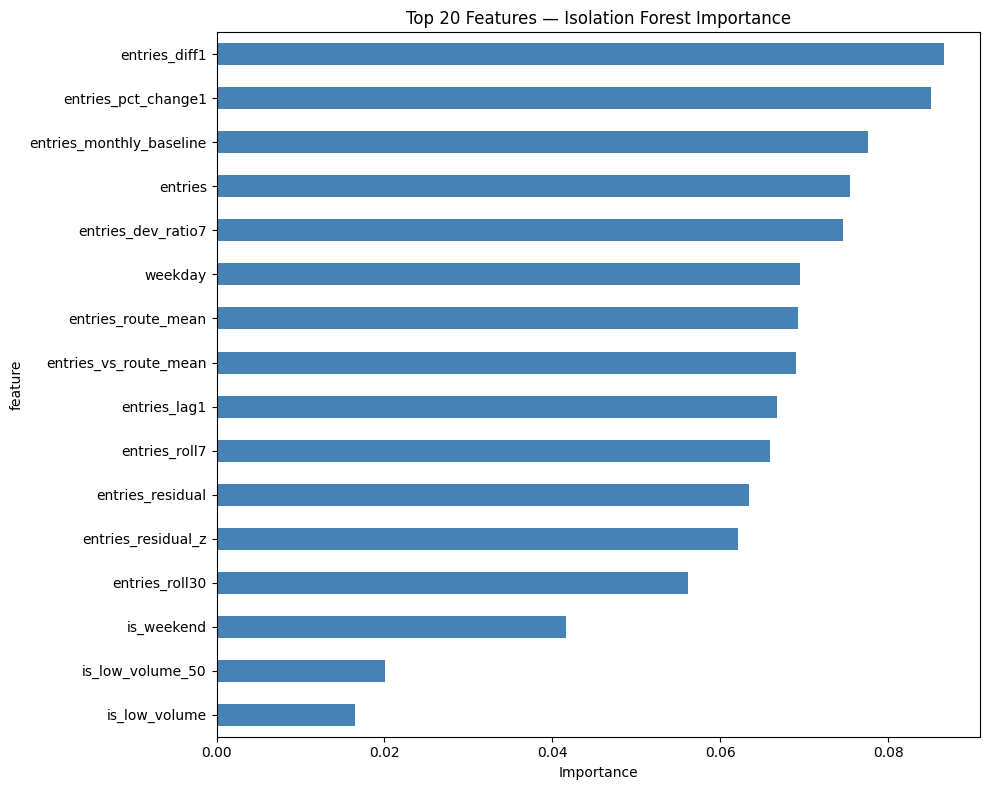

In [51]:
importances = np.zeros(len(feature_cols))
for tree in iso.estimators_:
    importances += tree.feature_importances_
importances /= len(iso.estimators_)

feat_imp = (pd.DataFrame({"feature": feature_cols, "importance": importances})
            .sort_values("importance", ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
feat_imp.head(top_n).plot.barh(x="feature", y="importance", ax=ax, legend=False, color="steelblue")
ax.invert_yaxis()
ax.set_title(f"Top {top_n} Features — Isolation Forest Importance")
ax.set_xlabel("Importance")
plt.tight_layout()

Here is where we end our time measurement

In [52]:
pipeline_end = time.time()
print(f"Classical pipeline execution time: {pipeline_end - pipeline_start:.2f} seconds")

Classical pipeline execution time: 1.42 seconds


## 6. Export

We save the full dataset enriched with baseline features, anomaly scores and labels. This file will be loaded by the post-processing notebook.

In [53]:
ANOMALY_DIR = IO_DIR / "anomaly_detection"
ANOMALY_DIR.mkdir(parents=True, exist_ok=True)
output_path = ANOMALY_DIR / "anomaly_scores.csv"
df.to_csv(output_path, index=False)

# Post-Processing Classical Pipeline

Input: anomaly_scores.csv  
Output: classical_anomaly_report.csv

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Load Anomaly Scores

In [55]:
ANOMALY_DIR = IO_DIR / "anomaly_detection"
df = pd.read_csv(ANOMALY_DIR / "anomaly_scores.csv")
df["date"] = pd.to_datetime(df["date"])

Same as before, we track the time

In [56]:
import time
pipeline_start = time.time()

## 2. Business Rules

Not all statistical anomalies are operationally meaningful, so we apply four domain-specific rules on top of the model output. We flag observations where the flag rate exceeds 3× its recent rolling average, where passenger volume exceeds 3× baseline, where entries deviate by more than 2σ from the monthly norm, or where the alarm density is above the 95th percentile. An observation that triggers any of these rules is marked as rule-flagged.

In [57]:
df["rule_entries_spike"] = (df["entries_dev_ratio7"] > 3).astype(int)
df["rule_high_residual_z"] = (df["entries_residual_z"].abs() > 2).astype(int)

df["rule_any"] = df[[
    "rule_entries_spike",
    "rule_high_residual_z"
]].max(axis=1)
print(f"Rules triggered: {df['rule_any'].sum()} / {len(df)}")

Rules triggered: 84 / 3256


## 3. Final Anomaly Label

The final anomaly label combines model consensus and business rules:

final_anomaly = consensus_anomaly OR rule_any

This ensures that:
Statistically unusual observations are captured even if no single business rule fires
Operationally meaningful patterns are captured even if the statistical models don't flag them

In [58]:
df["final_anomaly"] = ((df["consensus_anomaly"] == 1) | (df["rule_any"] == 1)).astype(int)
print(f"Final anomalies: {df['final_anomaly'].sum()} / {len(df)} ({df['final_anomaly'].mean():.1%})")

Final anomalies: 147 / 3256 (4.5%)


In [59]:
pipeline_end = time.time()
print(f"Classical pipeline execution time: {pipeline_end - pipeline_start:.2f} seconds")

Classical pipeline execution time: 0.01 seconds


## File Export

In [60]:
ANOMALY_DIR = IO_DIR / "anomaly_detection"
ANOMALY_DIR.mkdir(parents=True, exist_ok=True)
output_path = ANOMALY_DIR / "classical_post_processed.csv"
df.to_csv(output_path, index=False)

# Final Classical Output: Transit Anomaly Report

The last step turns the post-processed anomaly table into the final deliverable required by the project: a static transit anomaly report.  
The report ranks anomalous airport-route-nationality patterns, assigns an interpretable risk level, explains which statistical models and business rules triggered each case, and exports both machine-readable tables and presentation-ready figures.

In [61]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPORT_DIR = IO_DIR / "classical_report"
IMAGES_DIR = REPORT_DIR / "images"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# Work from the final post-processed dataframe created in the previous section.
report_df = df.copy()

print(f"Rows available for reporting: {len(report_df):,}")
print(f"Final anomalies available for reporting: {report_df['final_anomaly'].sum():,}")

Rows available for reporting: 3,256
Final anomalies available for reporting: 147


## 1. Output Calibration: Risk Score and Review Priority

The initial reporting approach applied fixed Low/Medium/High/Critical thresholds to a 0–100 risk score. However, in practice the observed scores remained well below the upper range, resulting in no observations being classified as High or Critical. This limited the operational usefulness of the output.

To address this, the revised framework separates two complementary components:

- **`risk_score`**: a continuous 0–100 severity measure derived from model signals, rule-based indicators, abnormal rates, and deviation features. This score reflects the relative intensity of anomalous behavior.

- **`review_priority`**: a calibrated ranking applied *only to flagged anomalies*, assigning them into tiers (e.g., Top / High / Medium / Low). This ensures a practical and actionable review queue, even when absolute risk scores remain moderate.

It is important to note that this framework does not constitute a supervised evaluation. In the absence of ground-truth anomaly labels, the output should be interpreted as a **prioritization mechanism** rather than a validated measure of predictive performance (e.g., precision or recall).

In [62]:
def robust_score(series, lower_q=0.01, upper_q=0.99):
    """Convert a numeric signal into a robust 0-1 score using percentile clipping."""
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if s.notna().sum() == 0:
        return pd.Series(0.0, index=s.index)
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    if pd.isna(lo) or pd.isna(hi) or hi <= lo:
        return pd.Series(0.0, index=s.index)
    return ((s.clip(lo, hi) - lo) / (hi - lo)).fillna(0.0)

# Clean numeric infinities before scoring.
for col in report_df.select_dtypes(include=[np.number]).columns:
    report_df[col] = report_df[col].replace([np.inf, -np.inf], np.nan)

# Model evidence: number of detectors agreeing, scaled 0-1.
model_cols = [c for c in ["iso_anomaly", "lof_anomaly", "zscore_anomaly"] if c in report_df.columns]
if "model_agreement" not in report_df.columns:
    report_df["model_agreement"] = report_df[model_cols].sum(axis=1) if model_cols else 0

# Rule evidence: number of business rules triggered, scaled 0-1.
rule_cols = [
    c for c in [
        "rule_flag_spike", "rule_entries_spike", "rule_high_residual_z", "rule_high_alarm"
    ] if c in report_df.columns
]
report_df["rule_count"] = report_df[rule_cols].sum(axis=1) if rule_cols else 0
max_rule_count = max(len(rule_cols), 1)

score_components = pd.DataFrame(index=report_df.index)
score_components["model_agreement"] = (report_df["model_agreement"] / max(len(model_cols), 1)).clip(0, 1)
score_components["rule_strength"] = (report_df["rule_count"] / max_rule_count).clip(0, 1)
score_components["entries_spike"] = robust_score(report_df.get("entries_dev_ratio7", 0))
score_components["seasonal_residual"] = robust_score(report_df.get("entries_residual_z", 0).abs())

weights = {
    "model_agreement": 0.40,
    "rule_strength": 0.25,
    "entries_spike": 0.20,
    "seasonal_residual": 0.15,
}

report_df["risk_score"] = sum(score_components[c] * w for c, w in weights.items()) * 100

# Keep non-anomalous rows in the full file, but do not let them dominate the operational queue.
report_df.loc[report_df["final_anomaly"] == 0, "risk_score"] *= 0.25
report_df["risk_score"] = report_df["risk_score"].round(2)

# Absolute risk levels describe raw severity; review priority describes rank among flagged anomalies.
report_df["risk_level"] = pd.cut(
    report_df["risk_score"],
    bins=[-0.01, 20, 40, 60, 100],
    labels=["Low", "Moderate", "High", "Critical"]
)

report_df["review_priority"] = "Not flagged"
flagged_mask = report_df["final_anomaly"] == 1
if flagged_mask.sum() > 0:
    flagged_scores = report_df.loc[flagged_mask, "risk_score"]
    q50, q80, q95 = flagged_scores.quantile([0.50, 0.80, 0.95])

    def assign_priority(score):
        if score >= q95:
            return "P1 - immediate review"
        if score >= q80:
            return "P2 - high priority"
        if score >= q50:
            return "P3 - standard review"
        return "P4 - monitor"

    report_df.loc[flagged_mask, "review_priority"] = flagged_scores.apply(assign_priority)

print("Risk-level distribution:")
print(report_df["risk_level"].value_counts().sort_index())
print("\nReview-priority distribution among final anomalies:")
print(report_df.loc[flagged_mask, "review_priority"].value_counts())

Risk-level distribution:
risk_level
Low         3109
Moderate      64
High          64
Critical      19
Name: count, dtype: int64

Review-priority distribution among final anomalies:
review_priority
P4 - monitor             73
P3 - standard review     44
P2 - high priority       21
P1 - immediate review     9
Name: count, dtype: int64


## 2. Evidence Type and Human-Readable Explanation

The previous output mixed model findings and business rules into one final anomaly flag. This made the system look more ML-driven than it really was. The revised report explicitly states whether each anomaly was triggered by model consensus, business rules, or both.

In [63]:
rule_label_map = {
    "rule_entries_spike": "passenger entries above recent baseline",
    "rule_high_residual_z": "seasonal residual unusually high",
}

model_label_map = {
    "iso_anomaly": "Isolation Forest",
    "lof_anomaly": "LOF",
    "zscore_anomaly": "Z-score",
}

def evidence_type(row):
    model_hit = bool(row.get("consensus_anomaly", 0) == 1)
    rule_hit = bool(row.get("rule_any", 0) == 1)
    if model_hit and rule_hit:
        return "Model + rules"
    if model_hit:
        return "Model consensus only"
    if rule_hit:
        return "Business rules only"
    return "Not flagged"


def build_explanation(row):
    triggered_models = [label for c, label in model_label_map.items() if c in row.index and row[c] == 1]
    triggered_rules = [label for c, label in rule_label_map.items() if c in row.index and row[c] == 1]

    parts = []
    if triggered_models:
        parts.append("Models: " + ", ".join(triggered_models))
    if triggered_rules:
        parts.append("Rules: " + "; ".join(triggered_rules))

    if not parts:
        return "Not flagged by the final anomaly logic"
    return " | ".join(parts)

report_df["evidence_type"] = report_df.apply(evidence_type, axis=1)
report_df["anomaly_explanation"] = report_df.apply(build_explanation, axis=1)

candidate_id_cols = [
    "date", "route_city", "AREOPORTO_ARRIVO", "AREOPORTO_PARTENZA",
    "CITTA_ARR", "CITTA_PARTENZA", "NAZIONALITA", "TIPO_DOCUMENTO"
]
id_cols = [c for c in candidate_id_cols if c in report_df.columns]

print("Identifier columns used:", id_cols)
print(report_df["evidence_type"].value_counts())

Identifier columns used: ['date', 'route_city']
evidence_type
Not flagged             3109
Model consensus only      63
Business rules only       59
Model + rules             25
Name: count, dtype: int64


## 3. Ranked Anomaly Report

The main operational deliverable is a sorted anomaly queue. It includes both `risk_score` and `review_priority`, plus explicit evidence columns so the user can see whether an alert came from ML agreement, rules, or both.

In [64]:
anomaly_report = (
    report_df.loc[report_df["final_anomaly"] == 1]
    .sort_values(["risk_score", "model_agreement", "rule_count"], ascending=False)
    .reset_index(drop=True)
)

priority_cols = [
    "risk_score", "risk_level", "review_priority", "evidence_type", "anomaly_explanation",
    "final_anomaly", "consensus_anomaly", "model_agreement", "rule_any", "rule_count",
    "iso_anomaly", "lof_anomaly", "zscore_anomaly",
    "entries", "allarmati", "investigati", "investigation_rate", "entries_dev_ratio7", "entries_residual_z"
]
available_priority_cols = [c for c in priority_cols if c in anomaly_report.columns]
final_cols = id_cols + available_priority_cols

top_anomalies = anomaly_report[final_cols].head(25)

print(f"Total final anomalies: {len(anomaly_report):,}")
print(f"Top review-priority cases: {(anomaly_report['review_priority'] == 'P1 - immediate review').sum():,}")
display(top_anomalies)

Total final anomalies: 147
Top review-priority cases: 9


,date,route_city,risk_score,risk_level,review_priority,evidence_type,anomaly_explanation,final_anomaly,consensus_anomaly,model_agreement,rule_any,rule_count,iso_anomaly,lof_anomaly,zscore_anomaly,entries,investigation_rate,entries_dev_ratio7,entries_residual_z
0,2024-01-18,ISTANBUL_BERGAMO,86.67,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,11,1.000000,5.500000,5.577323
1,2024-01-25,TEHRAN_ROMA,86.67,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,39,1.000000,4.875000,2.457755
2,2024-02-09,TIRANA_ROMA,86.67,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,359,0.233983,4.569091,4.896380
3,2024-02-10,LONDRA_VENEZIA,86.67,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,7,1.000000,4.900000,8.263713
4,2024-02-20,KABUL_BERGAMO,86.67,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,11,1.000000,5.500000,4.749083
5,2024-02-22,TEHRAN_ROMA,86.67,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,48,1.000000,4.480000,2.753161
6,2024-02-24,DUBAI_BERGAMO,86.67,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,7,1.000000,6.125000,4.834495
7,2024-02-24,ISTANBUL_ROMA,86.67,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,12,1.000000,6.461538,7.716988
8,2024-02-28,JEDDAH_ROMA,86.67,Critical,P1 - immediate review,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,64,0.000000,17.920000,11.844452
9,2024-02-28,TEHRAN_MILANO,84.97,Critical,P2 - high priority,Model + rules,"Models: Isolation Forest, Z-score | Rules: pas...",1,1,2,1,2,1,0,1,22,1.000000,3.208333,2.608531


## 4. Summary Tables for Results Interpretation

These tables are designed to make the output honest and interpretable. In particular, the evidence-type table shows how much of the final alert volume comes from model consensus versus rules.

In [65]:
summary_overall = pd.DataFrame({
    "metric": [
        "total_observations",
        "final_anomalies",
        "final_anomaly_rate",
        "model_consensus_anomalies",
        "business_rule_anomalies",
        "model_and_rule_overlap",
        "average_risk_score_all_rows",
        "average_risk_score_anomalies"
    ],
    "value": [
        len(report_df),
        int(report_df["final_anomaly"].sum()),
        round(report_df["final_anomaly"].mean(), 4),
        int(report_df.get("consensus_anomaly", pd.Series(0, index=report_df.index)).sum()),
        int(report_df.get("rule_any", pd.Series(0, index=report_df.index)).sum()),
        int(((report_df.get("consensus_anomaly", 0) == 1) & (report_df.get("rule_any", 0) == 1)).sum()),
        round(report_df["risk_score"].mean(), 2),
        round(report_df.loc[report_df["final_anomaly"] == 1, "risk_score"].mean(), 2)
    ]
})

risk_distribution = (
    report_df.groupby("risk_level", observed=False)
    .agg(observations=("final_anomaly", "size"),
         anomalies=("final_anomaly", "sum"),
         avg_risk_score=("risk_score", "mean"))
    .reset_index()
)

priority_distribution = (
    report_df.loc[report_df["final_anomaly"] == 1]
    .groupby("review_priority")
    .agg(anomalies=("final_anomaly", "size"),
         avg_risk_score=("risk_score", "mean"))
    .reset_index()
    .sort_values("avg_risk_score", ascending=False)
)

evidence_distribution = (
    report_df.loc[report_df["final_anomaly"] == 1]
    .groupby("evidence_type")
    .agg(anomalies=("final_anomaly", "size"),
         avg_risk_score=("risk_score", "mean"))
    .assign(share_of_anomalies=lambda x: x["anomalies"] / max(x["anomalies"].sum(), 1))
    .reset_index()
    .sort_values("anomalies", ascending=False)
)

group_col = "route_city" if "route_city" in report_df.columns else (id_cols[0] if id_cols else None)

if group_col:
    top_groups = (
        report_df.groupby(group_col)
        .agg(observations=("final_anomaly", "size"),
             anomalies=("final_anomaly", "sum"),
             avg_risk_score=("risk_score", "mean"),
             max_risk_score=("risk_score", "max"))
        .assign(anomaly_rate=lambda x: x["anomalies"] / x["observations"])
        .query("anomalies > 0")
        .sort_values(["anomalies", "max_risk_score"], ascending=False)
        .head(10)
        .reset_index()
    )
else:
    top_groups = pd.DataFrame()

display(summary_overall)
display(risk_distribution)
display(priority_distribution)
display(evidence_distribution)
display(top_groups)

,metric,value
0,total_observations,3256.0000
1,final_anomalies,147.0000
2,final_anomaly_rate,0.0451
3,model_consensus_anomalies,88.0000
4,business_rule_anomalies,84.0000
5,model_and_rule_overlap,25.0000
6,average_risk_score_all_rows,3.8800
7,average_risk_score_anomalies,46.2500


,risk_level,observations,anomalies,avg_risk_score
0,Low,3109,0,1.873155
1,Moderate,64,64,34.808594
2,High,64,64,48.159844
3,Critical,19,19,78.321579


,review_priority,anomalies,avg_risk_score
0,P1 - immediate review,9,86.670000
1,P2 - high priority,21,63.751429
2,P3 - standard review,44,47.367500
3,P4 - monitor,73,35.549452


,evidence_type,anomalies,avg_risk_score,share_of_anomalies
2,Model consensus only,63,36.773810,0.428571
0,Business rules only,59,46.411186,0.401361
1,Model + rules,25,69.723200,0.170068


,route_city,observations,anomalies,avg_risk_score,max_risk_score,anomaly_rate
0,TIRANA_BERGAMO,64,28,18.974531,57.31,0.437500
1,TIRANA_BOLOGNA,66,22,14.060909,53.98,0.333333
2,TIRANA_ROMA,120,9,6.142917,86.67,0.075000
3,TIRANA_GENOVA,48,6,8.841458,54.17,0.125000
4,TIRANA_PISA,68,6,5.699853,44.85,0.088235
5,JEDDAH_ROMA,25,4,10.407600,86.67,0.160000
6,TEHRAN_ROMA,23,4,11.714783,86.67,0.173913
7,TIRANA_MILANO,71,4,4.822958,55.74,0.056338
8,ISTANBUL_BOLOGNA,44,4,6.266818,52.13,0.090909
9,ISTANBUL_BERGAMO,48,3,5.562292,86.67,0.062500


## 5. Figures for the Final Presentation

The revised figures focus on operational interpretation: review priority, evidence type, top anomalous groups, and risk trend over time if dates are available.

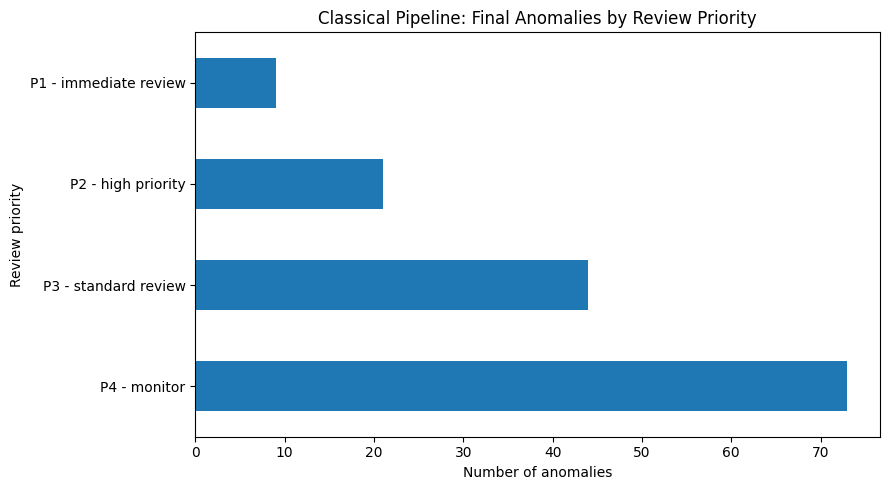

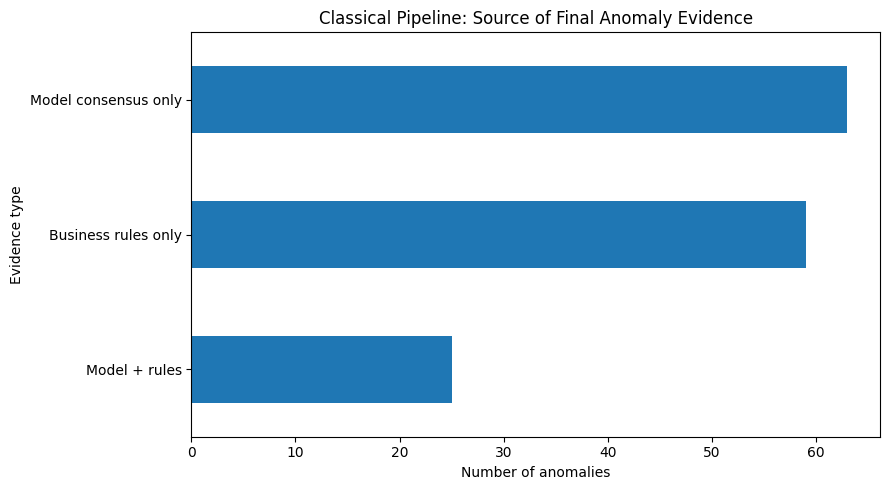

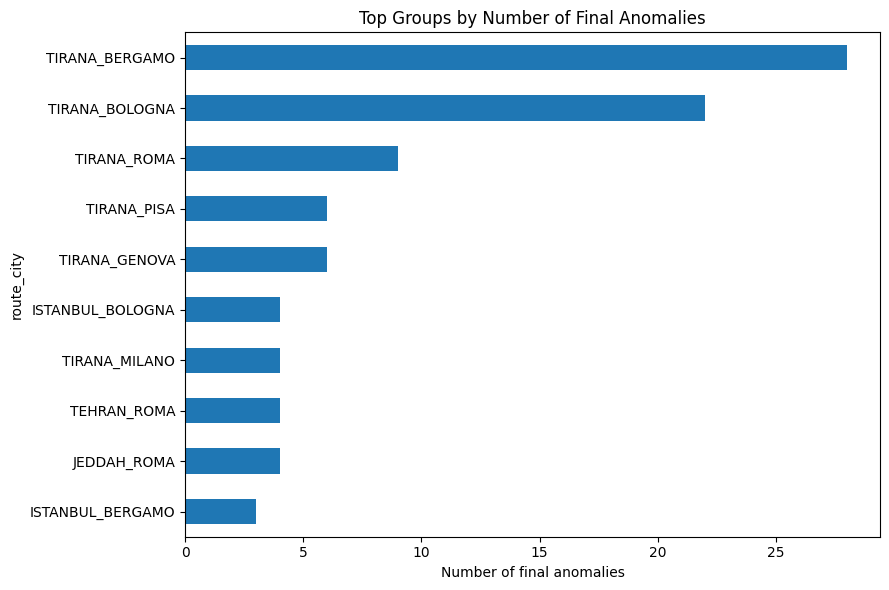

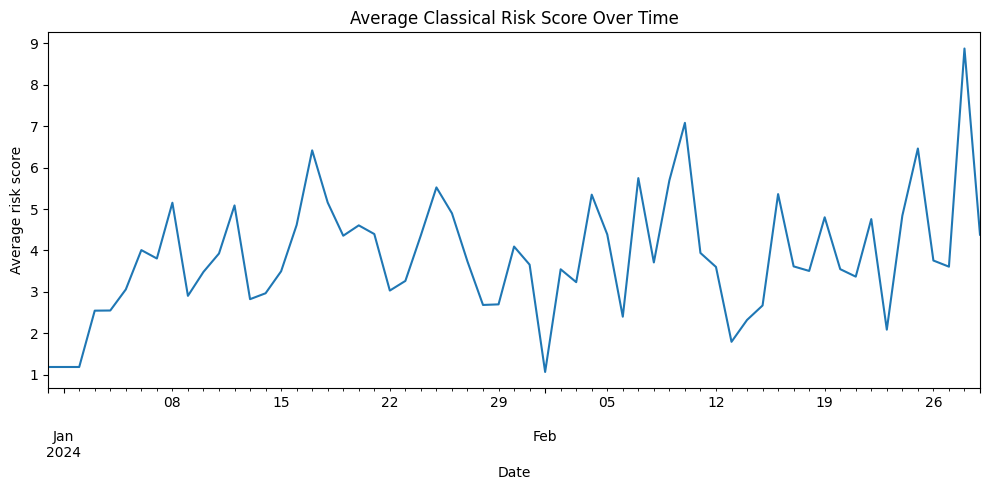

Figures saved in: /Users/kekm/Desktop/SEM 2/Machine Learning/Classical vs Multi-Agents/reply-classical-vs-multiagent-main/src/io/classical_report/images


In [66]:
# Figure 1: review-priority distribution among anomalies
if not priority_distribution.empty:
    ax = priority_distribution.sort_values("avg_risk_score").plot(
        kind="barh", x="review_priority", y="anomalies", legend=False, figsize=(9, 5)
    )
    ax.set_title("Classical Pipeline: Final Anomalies by Review Priority")
    ax.set_xlabel("Number of anomalies")
    ax.set_ylabel("Review priority")
    plt.tight_layout()
    priority_fig_path = IMAGES_DIR / "classical_review_priority_distribution.png"
    plt.savefig(priority_fig_path, dpi=150)
    plt.show()

# Figure 2: evidence type distribution
if not evidence_distribution.empty:
    ax = evidence_distribution.sort_values("anomalies").plot(
        kind="barh", x="evidence_type", y="anomalies", legend=False, figsize=(9, 5)
    )
    ax.set_title("Classical Pipeline: Source of Final Anomaly Evidence")
    ax.set_xlabel("Number of anomalies")
    ax.set_ylabel("Evidence type")
    plt.tight_layout()
    evidence_fig_path = IMAGES_DIR / "classical_evidence_type_distribution.png"
    plt.savefig(evidence_fig_path, dpi=150)
    plt.show()

# Figure 3: top anomalous groups
if not top_groups.empty:
    ax = top_groups.sort_values("anomalies").plot(
        kind="barh", x=group_col, y="anomalies", legend=False, figsize=(9, 6)
    )
    ax.set_title("Top Groups by Number of Final Anomalies")
    ax.set_xlabel("Number of final anomalies")
    ax.set_ylabel(group_col)
    plt.tight_layout()
    top_groups_fig_path = IMAGES_DIR / "classical_top_anomalous_groups.png"
    plt.savefig(top_groups_fig_path, dpi=150)
    plt.show()

# Figure 4: average risk over time
if "date" in report_df.columns:
    time_risk = (
        report_df.assign(date=pd.to_datetime(report_df["date"], errors="coerce"))
        .dropna(subset=["date"])
        .groupby("date")
        .agg(avg_risk_score=("risk_score", "mean"),
             anomalies=("final_anomaly", "sum"))
        .reset_index()
    )

    if not time_risk.empty:
        ax = time_risk.plot(x="date", y="avg_risk_score", legend=False, figsize=(10, 5))
        ax.set_title("Average Classical Risk Score Over Time")
        ax.set_xlabel("Date")
        ax.set_ylabel("Average risk score")
        plt.tight_layout()
        time_fig_path = IMAGES_DIR / "classical_risk_over_time.png"
        plt.savefig(time_fig_path, dpi=150)
        plt.show()

print(f"Figures saved in: {IMAGES_DIR}")

## 6. Export Final Classical Deliverables

The exported files now distinguish between the full scored dataset, the ranked anomaly queue, and a Markdown report that clearly states the limitation: without ground-truth labels, the output is an alert-prioritization report rather than a supervised performance evaluation.

In [67]:
full_output_path = REPORT_DIR / "classical_scored_full_dataset.csv"
anomaly_output_path = REPORT_DIR / "classical_ranked_anomaly_report.csv"
summary_output_path = REPORT_DIR / "classical_transit_anomaly_report.md"

report_df.to_csv(full_output_path, index=False)
anomaly_report[final_cols].to_csv(anomaly_output_path, index=False)

top_lines = []
for rank, (_, row) in enumerate(top_anomalies.head(10).iterrows(), start=1):
    identifier = " | ".join([f"{c}: {row[c]}" for c in id_cols if c in row.index])
    top_lines.append(
        f"{rank}. **{row['review_priority']} — score {row['risk_score']:.2f} ({row['risk_level']})**"
        + (f" — {identifier}" if identifier else "")
        + f" — {row['evidence_type']}: {row['anomaly_explanation']}"
    )

markdown_report = f"""# Classical Transit Anomaly Report

## Executive Summary

The classical anomaly detection pipeline processed **{len(report_df):,} observations** and flagged **{int(report_df['final_anomaly'].sum()):,} final anomalies**, corresponding to a final anomaly rate of **{report_df['final_anomaly'].mean():.2%}**.

This report should be interpreted as an **alert-prioritization output**, not as a supervised accuracy evaluation. No ground-truth anomaly labels are available, so precision, recall, F1-score, and ROC-AUC cannot be estimated reliably at this stage.

The final anomaly flag combines two evidence sources:

1. **Model consensus**: at least two classical detectors agree.
2. **Business-rule evidence**: operational thresholds identify unusual spikes or abnormal densities.

## Main Metrics

{summary_overall.to_markdown(index=False)}

## Absolute Risk-Level Distribution

{risk_distribution.to_markdown(index=False)}

## Review-Priority Distribution Among Final Anomalies

{priority_distribution.to_markdown(index=False)}

## Evidence-Type Distribution Among Final Anomalies

{evidence_distribution.to_markdown(index=False)}

## Top Anomalous Groups

{top_groups.to_markdown(index=False) if not top_groups.empty else "No group-level summary available."}

## Top 10 Ranked Anomalies

{chr(10).join(top_lines)}

## Interpretation

The ranked output should be used as an investigation queue. `P1 - immediate review` cases are the most unusual flagged records relative to the rest of the anomaly set. `P2` and `P3` cases remain relevant but require more contextual validation. `P4` cases are lower-priority alerts that may be useful for monitoring recurring patterns.

A high number of **Business rules only** cases means the final alert volume is strongly influenced by operational thresholds. This is useful for recall, but it may also increase false positives. The next improvement should therefore tune rule thresholds and validate the top-ranked anomalies using proxy labels or expert review.

## Files Generated

- `classical_scored_full_dataset.csv`
- `classical_ranked_anomaly_report.csv`
- `classical_transit_anomaly_report.md`
- figures saved under `images/`
"""

summary_output_path.write_text(markdown_report, encoding="utf-8")

print("Export completed.")
print(f"Full scored dataset: {full_output_path}")
print(f"Ranked anomaly report: {anomaly_output_path}")
print(f"Markdown report: {summary_output_path}")

Export completed.
Full scored dataset: /Users/kekm/Desktop/SEM 2/Machine Learning/Classical vs Multi-Agents/reply-classical-vs-multiagent-main/src/io/classical_report/classical_scored_full_dataset.csv
Ranked anomaly report: /Users/kekm/Desktop/SEM 2/Machine Learning/Classical vs Multi-Agents/reply-classical-vs-multiagent-main/src/io/classical_report/classical_ranked_anomaly_report.csv
Markdown report: /Users/kekm/Desktop/SEM 2/Machine Learning/Classical vs Multi-Agents/reply-classical-vs-multiagent-main/src/io/classical_report/classical_transit_anomaly_report.md
